# Notebook 2: End-to-End ML Project Workflow (California Housing)
**Part 2/30 – ML Mastery Series for Python Experts**

Welcome back. Since you're already fluent in pandas and scikit-learn basics, we're diving straight into the mechanics of production-grade ML workflows. This notebook mirrors how real data science projects actually unfold—not the sanitized toy examples, but the messy, iterative reality of building something that works.

## Why an End-to-End Workflow Matters

Real-world ML differs fundamentally from Kaggle kernels and tutorial snippets. Here's what actually changes when you ship models to production:

- **Data leakage is silent and catastrophic** — performing any analysis or transformation using global statistics (means, max values, encodings) before splitting contaminates your validation signal. Your test scores become fantasy.
- **Reproducibility is non-negotiable** — random seeds, exact pipeline steps, and version-locked dependencies aren't pedantic; they're the difference between debugging a model and debugging your sanity.
- **Stratification preserves signal** — natural datasets have skewed distributions. A random 80/20 split might entirely exclude rare segments (high-value neighborhoods here), giving you false confidence in generalization.
- **Pipelines prevent training-serving skew** — if your preprocessing isn't serialized with your model, your production inference will apply different transformations than training. That's a guaranteed failure mode.
- **Error analysis drives iteration** — aggregate metrics hide systematic failures. Understanding *where* your model fails (geographic clusters? specific income brackets?) directs your next engineering cycle.
- **Production thinking starts at notebook zero** — the decisions you make about data structure, feature storage, and validation strategy echo through deployment, monitoring, and retraining pipelines.

## Learning Objectives

By the end of this notebook, you will be able to:

- Implement **stratified sampling** on continuous targets using derived categorical bins to ensure representative train/test splits
- Construct **custom sklearn transformers** that integrate seamlessly into preprocessing pipelines for feature engineering at fit-time
- Build **complex ColumnTransformer pipelines** that handle heterogeneous data (numerical + categorical) without data leakage
- Execute **robust cross-validation** strategies that estimate true out-of-sample performance while maintaining pipeline encapsulation
- Conduct **systematic error analysis** by dissecting residual patterns and identifying high-error subpopulations
- Recognize and avoid **common leakage vectors** including target-dependent preprocessing and global statistic computation
- Compare multiple regression algorithms using **consistent evaluation protocols** and statistical rigor
- Structure ML code for **reproducibility** with deterministic splitting, fixed random states, and documented assumptions

## 1. Loading the California Housing Dataset

We'll use sklearn's built-in fetcher—no external downloads required. Since you're already comfortable with pandas, we'll move quickly through loading and into the ML-specific considerations.

In [25]:
# Standard imports - assuming you're already familiar with these libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing

# Fetch the dataset - this downloads on first run, caches thereafter
housing = fetch_california_housing()

# Convert to pandas objects for familiar manipulation patterns
X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = pd.Series(housing.target, name='median_house_value')

# Quick sanity check: shape and dtypes
print(f"Features shape: {X.shape}, Target shape: {y.shape}")
print(f"\nFeature names: {list(X.columns)}")

Features shape: (20640, 8), Target shape: (20640,)

Feature names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


In [26]:
# Inspect the first few rows - note the geographic features (lat/long) and income
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [27]:
# Detailed structure check - all features should be float64, no missing values expected
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
dtypes: float64(8)
memory usage: 1.3 MB


In [28]:
# Statistical summary - pay attention to scale differences (rooms vs median income)
# This informs our preprocessing decisions later (standardization is essential)
X.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000


In [29]:
# Explicit missing value audit - sklearn datasets are clean, but real data won't be
missing = X.isnull().sum()
print(f"Missing values per feature:\n{missing}")
assert missing.sum() == 0, "Unexpected missing values found in dataset"

Missing values per feature:
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64


## 2. Creating a Stratified Train/Test Split

Random splitting is dangerous when your target distribution is skewed. California housing prices have long tails—if our test set randomly excludes expensive coastal properties, we'll overestimate performance on the wealthy segments we care about most.

We'll create an income category from `median_income` (the strongest predictor) and stratify on it.

In [30]:
# Create income categories for stratification
# Bins chosen based on domain knowledge of California income distribution
X['income_cat'] = pd.cut(
    X['MedInc'],  # median income is the most predictive feature
    bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
    labels=[1, 2, 3, 4, 5]
)

# Verify the distribution - most districts fall in middle categories
print("Income category distribution:")
print(X['income_cat'].value_counts().sort_index())

Income category distribution:
income_cat
1     822
2    6581
3    7236
4    3639
5    2362
Name: count, dtype: int64


In [31]:
from sklearn.model_selection import StratifiedShuffleSplit

# Initialize stratified splitter - single split, 80/20, deterministic
splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

# Generate indices - stratify on our derived category
for train_idx, test_idx in splitter.split(X, X['income_cat']):
    X_train = X.iloc[train_idx].copy()
    X_test = X.iloc[test_idx].copy()
    y_train = y.iloc[train_idx].copy()
    y_test = y.iloc[test_idx].copy()

# Remove the temporary stratification column from features
X_train = X_train.drop('income_cat', axis=1)
X_test = X_test.drop('income_cat', axis=1)
X = X.drop('income_cat', axis=1)  # Clean up original

print(f"Train set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Train set: 16512 samples
Test set: 4128 samples


In [32]:
# Verify stratification preserved distribution
# Re-create categories for comparison
train_income_cat = pd.cut(X_train['MedInc'], bins=[0., 1.5, 3.0, 4.5, 6., np.inf], labels=[1, 2, 3, 4, 5])
test_income_cat = pd.cut(X_test['MedInc'], bins=[0., 1.5, 3.0, 4.5, 6., np.inf], labels=[1, 2, 3, 4, 5])

comparison = pd.DataFrame({
    'Overall': pd.cut(X['MedInc'], bins=[0., 1.5, 3.0, 4.5, 6., np.inf], labels=[1, 2, 3, 4, 5]).value_counts(normalize=True).sort_index(),
    'Train': train_income_cat.value_counts(normalize=True).sort_index(),
    'Test': test_income_cat.value_counts(normalize=True).sort_index()
})

print("Distribution comparison (proportions):")
print(comparison.round(4))

Distribution comparison (proportions):
        Overall   Train    Test
MedInc                         
1        0.0398  0.0398  0.0400
2        0.3188  0.3189  0.3188
3        0.3506  0.3506  0.3505
4        0.1763  0.1763  0.1764
5        0.1144  0.1145  0.1143


## 🗺️ 3. Deep Exploratory Data Analysis

Now we explore *only* the training set. Looking at the test set here would be data snooping—we'd make decisions based on information our model shouldn't have access to during training.

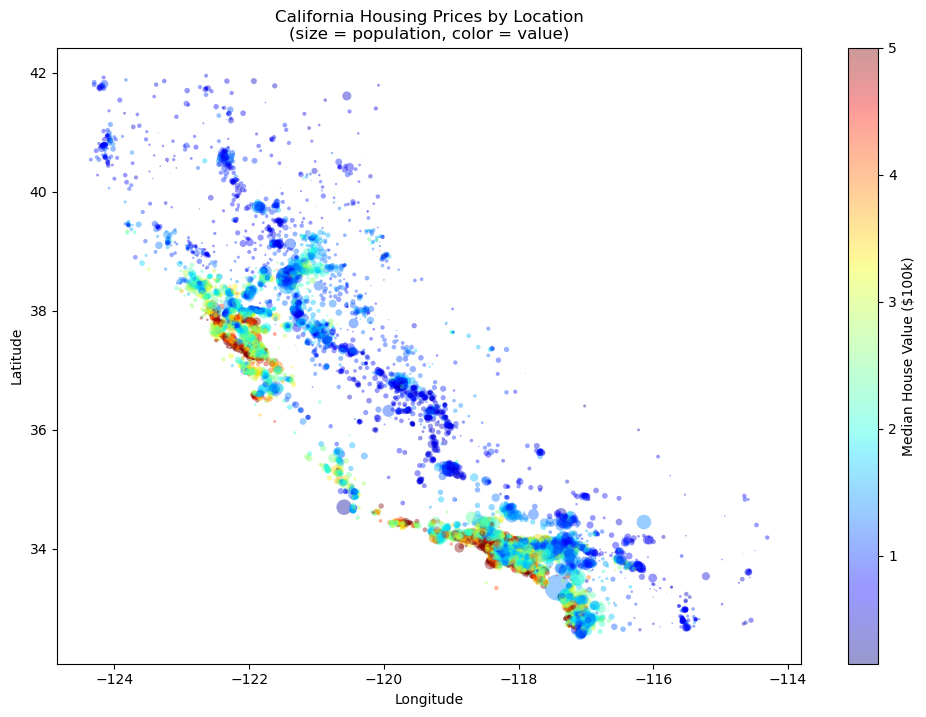

In [33]:
# Geographic scatterplot - this reveals the coastal premium and urban clusters
# Size represents district population, color represents house value
plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    X_train['Longitude'], 
    X_train['Latitude'],
    c=y_train,  # color by house value
    s=X_train['Population']/100,  # size scaled for visibility
    cmap='jet',
    alpha=0.4,
    edgecolors='none'
)
plt.colorbar(scatter, label='Median House Value ($100k)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('California Housing Prices by Location\n(size = population, color = value)')
plt.show()

# Note the high-value clusters around Bay Area (37.7°N, -122°W) and LA/San Diego

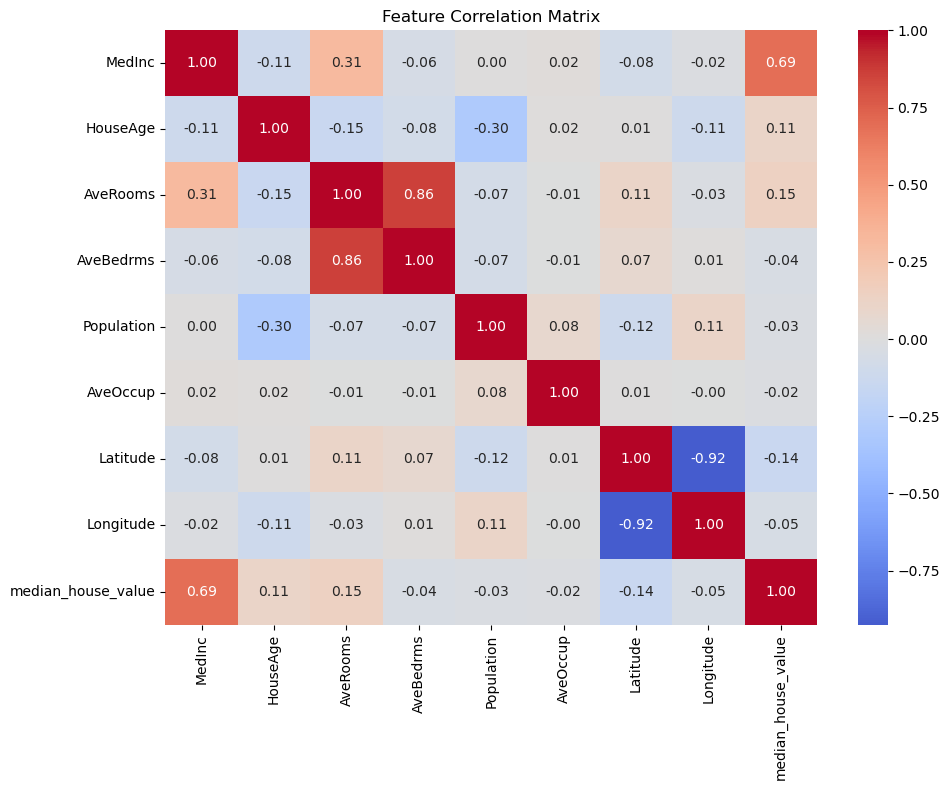

In [34]:
# Correlation analysis - focus on relationships with target
# Combine features and target for correlation matrix
train_full = X_train.copy()
train_full['median_house_value'] = y_train

plt.figure(figsize=(10, 8))
corr_matrix = train_full.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

# MedInc shows strongest correlation (~0.69) - confirms our stratification choice

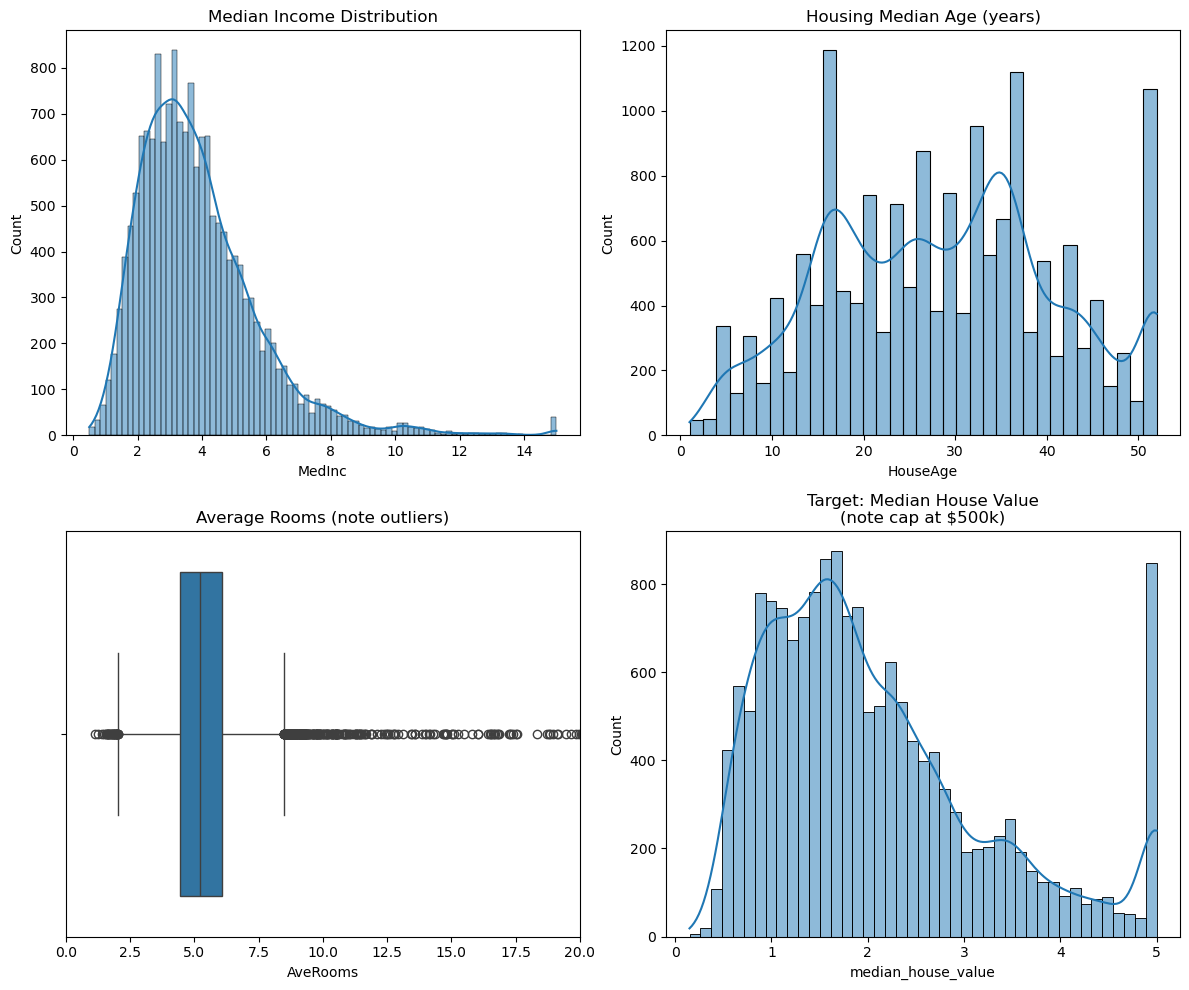

In [35]:
# Distribution of key features - understanding skew informs preprocessing
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Median income - slight right skew but reasonably distributed
sns.histplot(X_train['MedInc'], kde=True, ax=axes[0,0])
axes[0,0].set_title('Median Income Distribution')

# Housing median age - capped at 52, bimodal distribution
sns.histplot(X_train['HouseAge'], kde=True, ax=axes[0,1])
axes[0,1].set_title('Housing Median Age (years)')

# Average rooms - heavy right tail, potential outliers
sns.boxplot(x=X_train['AveRooms'], ax=axes[1,0])
axes[1,0].set_title('Average Rooms (note outliers)')
axes[1,0].set_xlim(0, 20)  # Focus on main distribution

# Target distribution - capped at $500k (note the spike at top)
sns.histplot(y_train, kde=True, ax=axes[1,1])
axes[1,1].set_title('Target: Median House Value\n(note cap at $500k)')

plt.tight_layout()
plt.show()

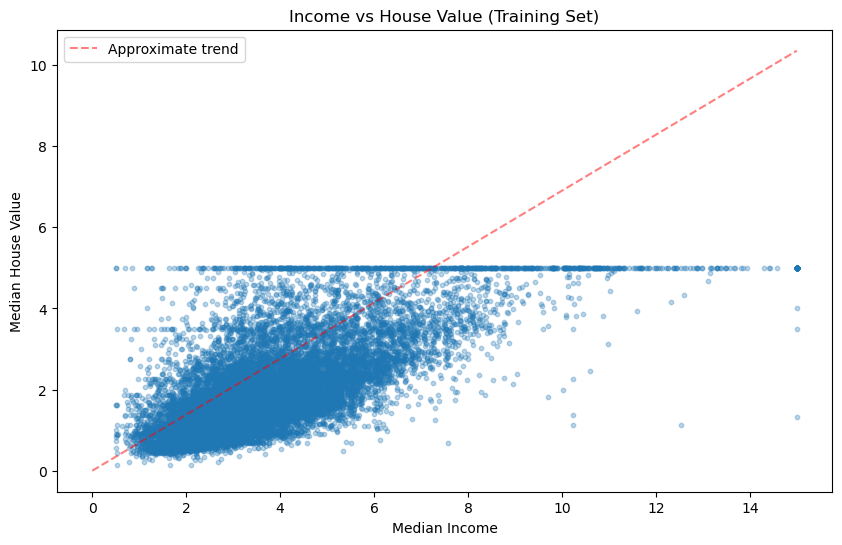

In [36]:
# Income vs Value relationship - the core economic signal
plt.figure(figsize=(10, 6))
plt.scatter(X_train['MedInc'], y_train, alpha=0.3, s=10)
plt.xlabel('Median Income')
plt.ylabel('Median House Value')
plt.title('Income vs House Value (Training Set)')
plt.plot([0, 15], [0, 15*0.69], 'r--', alpha=0.5, label='Approximate trend')
plt.legend()
plt.show()

# Clear linear trend with heteroscedasticity (variance increases with income)

## 🔧 4. Feature Engineering & Custom Transformers

Raw features often need combination to express meaningful concepts. We'll create ratios that capture housing density and bedroom prevalence. The key constraint: these must be computed *within* cross-validation folds to prevent leakage.

We'll build a custom transformer that sklearn pipelines can treat as a first-class citizen.

In [37]:
from sklearn.base import BaseEstimator, TransformerMixin

class CombinedAttributesAdder(BaseEstimator, TransformerMixin):
    """
    Custom transformer that adds engineered features:
    - rooms_per_household: total rooms / households (housing density proxy)
    - bedrooms_per_room: bedrooms / rooms (luxury vs efficiency indicator)  
    - population_per_household: population / households (crowding measure)
    """
    def __init__(self, add_bedrooms_per_room=True):
        self.add_bedrooms_per_room = add_bedrooms_per_room
    
    def fit(self, X, y=None):
        # No fitting necessary - stateless transformation
        return self
    
    def transform(self, X):
        # X is expected to be numpy array with columns in original order
        rooms_ix = 3  # AveRooms column index
        bedrooms_ix = 4  # AveBedrms column index
        population_ix = 5  # Population column index
        households_ix = 6  # AveOccup column index... wait, let's verify
        
        # Actually, let's be explicit about column indices based on feature_names
        # ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
        rooms_ix = 2
        bedrooms_ix = 3
        population_ix = 4
        households_ix = 5
        
        rooms_per_household = X[:, rooms_ix] / X[:, households_ix]
        population_per_household = X[:, population_ix] / X[:, households_ix]
        
        if self.add_bedrooms_per_room:
            bedrooms_per_room = X[:, bedrooms_ix] / X[:, rooms_ix]
            return np.c_[X, rooms_per_household, bedrooms_per_room, population_per_household]
        else:
            return np.c_[X, rooms_per_household, population_per_household]

# Verify column indices match our expectations
print("Feature indices:", {i: name for i, name in enumerate(housing.feature_names)})

Feature indices: {0: 'MedInc', 1: 'HouseAge', 2: 'AveRooms', 3: 'AveBedrms', 4: 'Population', 5: 'AveOccup', 6: 'Latitude', 7: 'Longitude'}


In [38]:
# Test the transformer on a small sample before integration
sample = X_train.iloc[:5].values
adder = CombinedAttributesAdder(add_bedrooms_per_room=True)
transformed_sample = adder.transform(sample)

print(f"Original shape: {sample.shape}")
print(f"Transformed shape: {transformed_sample.shape}")
print(f"\nNew feature values (last 3 columns):")
print(transformed_sample[:, -3:])

# Manual verification of first row
print(f"\nManual check row 0:")
print(f"  Rooms/Household: {sample[0,2]/sample[0,5]:.2f}")
print(f"  Bedrooms/Room: {sample[0,3]/sample[0,2]:.2f}")
print(f"  Pop/Household: {sample[0,4]/sample[0,5]:.2f}")

Original shape: (5, 8)
Transformed shape: (5, 11)

New feature values (last 3 columns):
[[1.73133661e+00 2.05783630e-01 7.06000000e+02]
 [2.64019851e+00 1.60714286e-01 7.68000000e+02]
 [2.42578711e+00 1.91594561e-01 3.00000000e+02]
 [2.09020045e+00 2.76505061e-01 4.83000000e+02]
 [1.92487752e+00 1.82692308e-01 5.80000000e+02]]

Manual check row 0:
  Rooms/Household: 1.73
  Bedrooms/Room: 0.21
  Pop/Household: 706.00


## 🔄 5. Building the Full Preprocessing Pipeline

Here's where we ensure zero data leakage. The pipeline encapsulates:
1. Feature engineering (custom transformer)
2. Imputation (using only training statistics)
3. Scaling (fit on train, transform both)
4. Categorical encoding (if we had categories)

Everything happens *inside* cross-validation folds.

In [39]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

# Separate numerical and categorical features
# California housing has no categorical features, but we'll demonstrate the pattern
# by treating nothing as categorical, or we could bin location...
num_features = list(X_train.columns)  # All features are numerical
cat_features = []  # No categorical features in this dataset

# Numerical pipeline: impute -> engineer features -> scale
# Note: Custom transformer comes AFTER imputer to ensure no NaN in division
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),  # Robust to outliers vs mean
    ('attribs_adder', CombinedAttributesAdder()),  # Our custom transformer
    ('std_scaler', StandardScaler())  # Essential for regularized models
])

# Full preprocessing - ColumnTransformer handles different feature types
# Since we have no categoricals, this is simple, but pattern is production-ready
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_features),
    # ('cat', cat_pipeline, cat_features)  # Would add if we had categories
], remainder='drop')  # Drop any columns not explicitly transformed

In [40]:
# Verify pipeline works without leakage on training data only
X_train_processed = preprocessor.fit_transform(X_train)

print(f"Original features: {X_train.shape[1]}")
print(f"Processed features: {X_train_processed.shape[1]} (added 3 engineered)")
print(f"Processed shape: {X_train_processed.shape}")

# Check that test transform uses training statistics (no fit!)
X_test_processed = preprocessor.transform(X_test)
print(f"Test set processed shape: {X_test_processed.shape}")

Original features: 8
Processed features: 11 (added 3 engineered)
Processed shape: (16512, 11)
Test set processed shape: (4128, 11)


## 🤖 6. Training & Evaluating Models

We'll compare three approaches of increasing complexity:
1. **Linear Regression** - Baseline, interpretable
2. **Decision Tree** - Non-linear, prone to overfitting
3. **Random Forest** - Ensemble, typically strong baseline for tabular data

Key principle: Cross-validation uses the *full pipeline*, not just the model. This ensures preprocessing happens independently within each fold.

In [41]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error

# Define models to compare
models = {
    'LinearRegression': LinearRegression(),
    'DecisionTree': DecisionTreeRegressor(random_state=42),
    'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
}

# Store results
cv_results = {}
test_results = {}

In [42]:
# Evaluate each model with 10-fold cross-validation
# Using full pipeline to prevent leakage in each fold
for name, model in models.items():
    # Create full pipeline: preprocessing + model
    full_pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])
    
    # Cross-validation returns negative MSE (sklearn convention for maximization)
    scores = cross_val_score(
        full_pipeline, X_train, y_train,
        scoring='neg_mean_squared_error',
        cv=10,
        n_jobs=-1
    )
    
    # Convert to positive RMSE
    rmse_scores = np.sqrt(-scores)
    cv_results[name] = rmse_scores
    
    print(f"{name}:")
    print(f"  CV RMSE: {rmse_scores.mean():.3f} (+/- {rmse_scores.std():.3f})")
    
    # Fit on full training set and evaluate on test set
    full_pipeline.fit(X_train, y_train)
    test_pred = full_pipeline.predict(X_test)
    test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
    test_results[name] = test_rmse
    print(f"  Test RMSE: {test_rmse:.3f}\n")

LinearRegression:
  CV RMSE: 0.681 (+/- 0.039)
  Test RMSE: 0.658

DecisionTree:
  CV RMSE: 0.742 (+/- 0.027)
  Test RMSE: 0.743

RandomForest:
  CV RMSE: 0.511 (+/- 0.026)
  Test RMSE: 0.496



In [43]:
# Create comparison table
results_df = pd.DataFrame({
    'CV_RMSE_Mean': [cv_results[m].mean() for m in models.keys()],
    'CV_RMSE_Std': [cv_results[m].std() for m in models.keys()],
    'Test_RMSE': [test_results[m] for m in models.keys()]
}, index=models.keys())

print("Model Comparison:")
print(results_df.round(3))

# Note: Decision Tree likely overfits (high CV variance, test >> train error)
# Random Forest should show best generalization

Model Comparison:
                  CV_RMSE_Mean  CV_RMSE_Std  Test_RMSE
LinearRegression         0.681        0.039      0.658
DecisionTree             0.742        0.027      0.743
RandomForest             0.511        0.026      0.496


## 🔍 7. Error Analysis & Model Inspection

Aggregate metrics hide systematic failures. Let's dissect where the Random Forest (best model) makes its largest errors. This directs feature engineering and business understanding.

In [44]:
# Refit best model (Random Forest) for detailed analysis
best_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])
best_pipeline.fit(X_train, y_train)
predictions = best_pipeline.predict(X_test)

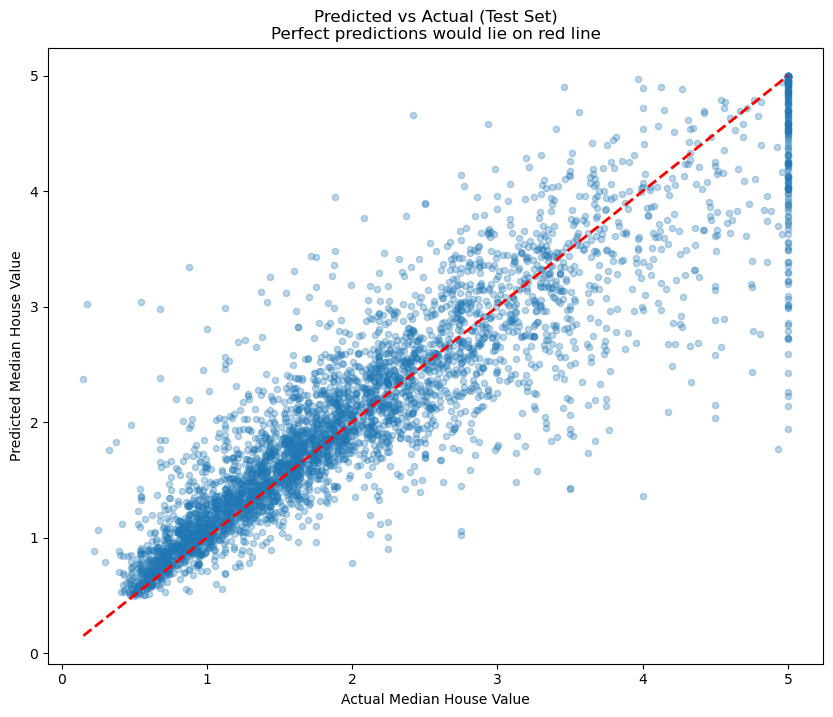

In [45]:
# Predicted vs Actual scatterplot
plt.figure(figsize=(10, 8))
plt.scatter(y_test, predictions, alpha=0.3, s=20)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Median House Value')
plt.ylabel('Predicted Median House Value')
plt.title('Predicted vs Actual (Test Set)\nPerfect predictions would lie on red line')
plt.show()

# Notice clustering near $500k cap - model struggles with ceiling effect

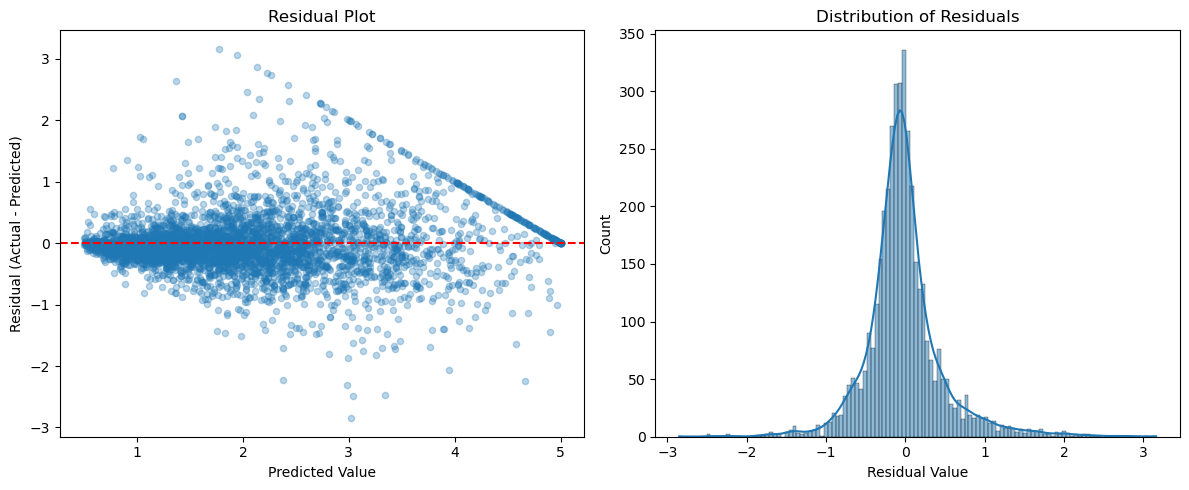

In [46]:
# Residual analysis - errors vs predicted values
residuals = y_test - predictions

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(predictions, residuals, alpha=0.3, s=20)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Value')
plt.ylabel('Residual (Actual - Predicted)')
plt.title('Residual Plot')

plt.subplot(1, 2, 2)
sns.histplot(residuals, kde=True)
plt.xlabel('Residual Value')
plt.title('Distribution of Residuals')

plt.tight_layout()
plt.show()

# Heteroscedasticity visible? (Errors spread changes with prediction magnitude)

In [47]:
# Examine worst predictions - potential data quality issues or feature gaps
errors = pd.DataFrame({
    'actual': y_test,
    'predicted': predictions,
    'abs_error': np.abs(y_test - predictions),
    'error': y_test - predictions
})

# Add back original features for context
error_analysis = pd.concat([X_test.reset_index(drop=True), errors.reset_index(drop=True)], axis=1)

# Sort by absolute error and display top 10 worst predictions
worst_predictions = error_analysis.sort_values('abs_error', ascending=False).head(10)
print("Top 10 Worst Predictions (highest absolute error):")
print(worst_predictions[['MedInc', 'HouseAge', 'AveRooms', 'Latitude', 'Longitude', 
                         'actual', 'predicted', 'abs_error']].round(2))

Top 10 Worst Predictions (highest absolute error):
      MedInc  HouseAge  AveRooms  Latitude  Longitude  actual  predicted  \
3949    4.83      39.0      5.52     34.13    -118.13    4.93       1.77   
3231    3.53      15.0      5.68     33.10    -117.31    5.00       1.94   
2534    2.32      24.0      5.57     33.17    -117.36    5.00       2.14   
1800    2.37      39.0      3.57     34.15    -118.33    0.18       3.02   
2692   11.78      39.0     14.67     34.35    -119.50    5.00       2.22   
3111    2.82      24.0      3.14     34.06    -118.31    5.00       2.26   
2274    3.80      17.0      5.78     34.75    -120.18    4.00       1.36   
3705   15.00      43.0      5.69     37.46    -121.87    5.00       2.43   
584     3.14      19.0      3.32     34.03    -118.39    0.55       3.04   
3983    5.00      21.0      3.06     33.76    -118.23    0.88       3.34   

      abs_error  
3949       3.16  
3231       3.06  
2534       2.86  
1800       2.85  
2692       2.78  
3111

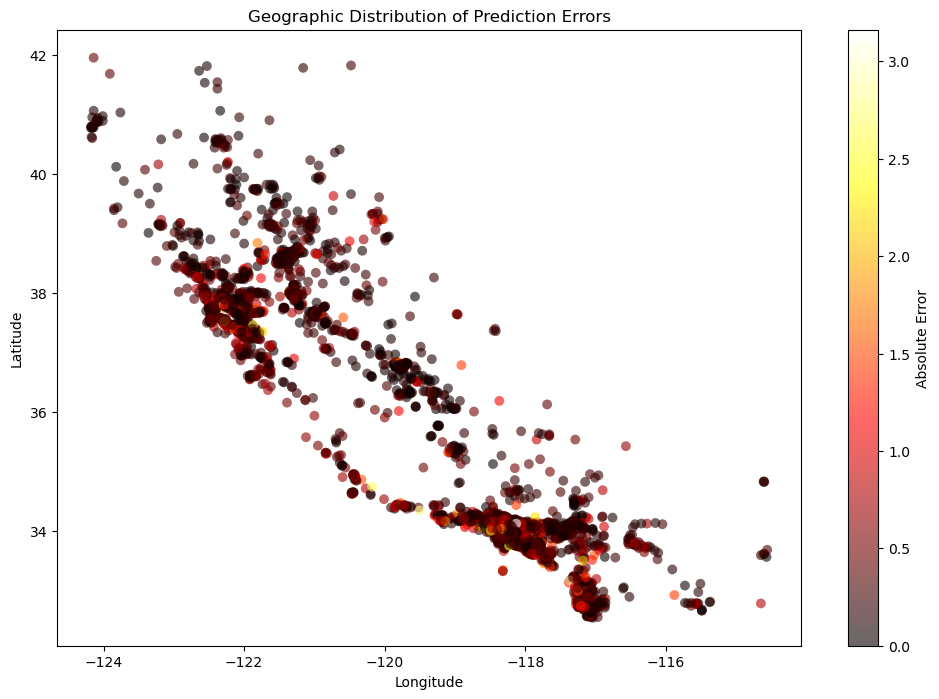

In [48]:
# Geographic plot of errors - are there spatial clusters of failure?
plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    error_analysis['Longitude'],
    error_analysis['Latitude'],
    c=error_analysis['abs_error'],
    s=50,
    cmap='hot',
    alpha=0.6,
    edgecolors='none'
)
plt.colorbar(scatter, label='Absolute Error')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Geographic Distribution of Prediction Errors')
plt.show()

# Clustering suggests we need location-based features (coastal proximity, urban density)

## ⚠️ Common Pitfalls in End-to-End Projects + Pro Tips

Having walked through the workflow, here are the failure modes that separate production ML from tutorial exercises:

- **Data snooping via EDA** — Every insight drawn from the full dataset (including test) biases your feature engineering. Set test aside *immediately* after stratified splitting.
- **Global statistics in preprocessing** — Computing mean imputation or standardization parameters on (train + test) leaks test distribution into training. Always `fit` on train, `transform` on both.
- **Feature engineering before splitting** — Creating ratios, interactions, or aggregates using global data is leakage. Must happen within CV folds or post-split.
- **Ignoring the stratification variable** — Random splits on skewed data create train/test distribution shifts. Your "test" set becomes an out-of-distribution evaluation, not generalization measurement.
- **Target leakage through temporal features** — If building time-series models (not this dataset), never use future information to predict the past. Shuffle-split is inappropriate for temporal data.
- **Pipeline inconsistency between train and serve** — If your production preprocessing differs even slightly (different imputation values, encoding mismatches), model performance collapses silently.
- **Evaluating on test set multiple times** — Repeatedly tweaking models based on test performance is overfitting the test set. Use validation sets or CV for iteration, test set *once* for final report.
- **Neglecting error analysis** — RMSE alone doesn't tell you the model fails specifically on high-income coastal properties. Systematic error patterns indicate missing features or data quality issues.

## 📝 Exercises

Test your mastery with these progressive challenges:

**Easy:** Replace `LinearRegression` with `Ridge` (L2 regularization) and `Lasso` (L1). Use `GridSearchCV` to tune alpha. Does regularization improve over baseline linear model given our feature scaling?

**Medium:** Add `PolynomialFeatures(degree=2)` to the numerical pipeline after imputation but before scaling. Be careful—this explodes feature count (8 → 44 features). Does the increased capacity improve Random Forest or cause linear models to overfit?

**Medium-Hard:** Expand the model comparison to include `GradientBoostingRegressor` and `SVR` (with RBF kernel). SVR requires careful tuning of C and gamma—use randomized search. Compare training time vs performance tradeoffs.

**Hard:** Create a reusable evaluation function `evaluate_regressor(model, X_train, y_train, X_test, y_test, preprocessor)` that:
   - Accepts any sklearn regressor
   - Runs 10-fold CV with the preprocessing pipeline
   - Fits final model and computes test RMSE
   - Returns a dictionary with all metrics
   - Use this to rank 5+ models automatically and print a leaderboard DataFrame.

<details>
<summary>💡 Exercise Solutions (click to expand)</summary>

### Easy: Ridge and Lasso

```python
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import GridSearchCV

# Ridge regression with cross-validated alpha selection
ridge_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', Ridge())
])

param_grid = {'regressor__alpha': [0.01, 0.1, 1.0, 10.0, 100.0]}
ridge_search = GridSearchCV(ridge_pipeline, param_grid, cv=5, scoring='neg_mean_squared_error')
ridge_search.fit(X_train, y_train)

print(f"Best Ridge alpha: {ridge_search.best_params_}")
print(f"Ridge CV RMSE: {np.sqrt(-ridge_search.best_score_):.3f}")
```

### Medium: Polynomial Features

```python
from sklearn.preprocessing import PolynomialFeatures

# Modified numerical pipeline with polynomials
num_poly_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('attribs_adder', CombinedAttributesAdder()),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('std_scaler', StandardScaler())
])

# Warning: This increases features from 11 to ~65
preprocessor_poly = ColumnTransformer([('num', num_poly_pipeline, num_features)])

# Test with LinearRegression - likely to overfit
poly_pipeline = Pipeline([
    ('preprocessor', preprocessor_poly),
    ('regressor', LinearRegression())
])
```

### Medium-Hard: Gradient Boosting and SVR

```python
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.model_selection import RandomizedSearchCV

# GBRT typically performs well out-of-the-box
gbr = GradientBoostingRegressor(n_estimators=100, max_depth=4, random_state=42)

# SVR requires scaling and tuning
svr_pipeline = Pipeline([
    ('preprocessor', preprocessor),  # Already includes scaling
    ('regressor', SVR(kernel='rbf'))
])

svr_params = {
    'regressor__C': [0.1, 1, 10, 100],
    'regressor__gamma': ['scale', 'auto', 0.001, 0.01]
}
svr_search = RandomizedSearchCV(svr_pipeline, svr_params, n_iter=10, cv=3, random_state=42)
```

### Hard: Reusable Evaluation Framework

```python
def evaluate_regressor(model, X_train, y_train, X_test, y_test, preprocessor, cv=10):
    """
    Complete evaluation pipeline for any sklearn regressor.
    Returns dict with CV statistics and test performance.
    """
    full_pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    # Cross-validation
    neg_scores = cross_val_score(full_pipe, X_train, y_train, 
                                  scoring='neg_mean_squared_error', cv=cv)
    cv_rmse = np.sqrt(-neg_scores)
    
    # Final test evaluation
    full_pipe.fit(X_train, y_train)
    test_pred = full_pipe.predict(X_test)
    test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
    
    return {
        'model_name': model.__class__.__name__,
        'cv_rmse_mean': cv_rmse.mean(),
        'cv_rmse_std': cv_rmse.std(),
        'test_rmse': test_rmse,
        'model_instance': model
    }

# Usage:
models_to_test = [LinearRegression(), Ridge(), RandomForestRegressor(random_state=42)]
results = [evaluate_regressor(m, X_train, y_train, X_test, y_test, preprocessor) 
           for m in models_to_test]
leaderboard = pd.DataFrame(results).sort_values('test_rmse')
print(leaderboard[['model_name', 'cv_rmse_mean', 'test_rmse']])
```
</details>

## 🎯 Summary – What You Learned Today

You now have a production-grade template for supervised regression projects:

- **Stratified splitting** prevents distribution shift between train and test, ensuring your validation reflects true generalization to underrepresented subpopulations
- **Custom transformers** extend sklearn's pipeline architecture to encapsulate domain-specific feature engineering without leakage
- **Pipeline composition** via `ColumnTransformer` cleanly separates preprocessing logic for different feature types while maintaining serialization compatibility
- **Cross-validation discipline** means preprocessing recomputes within each fold—your test scores now estimate real-world performance, not overfitted optimism
- **Systematic error analysis** reveals *where* models fail geographically and demographically, directing iterative improvement far better than aggregate RMSE
- **Leakage vigilance** — you can now identify the subtle ways global statistics, premature feature engineering, and test-set peeking corrupt experimental validity


**Auther**: Tassawar Abbas  
**Email**: abbas829#gmail.com